Week 1: 

Submit a .py script that concatenates all monthly files from January 2024 through the most recently
completed calendar month into two combined datasets (listings and sold), filters both to PropertyType ==
‘Residential’ only, and saves them as new CSVs. 

Include comments confirming row counts before and
after concatenation and before and after the Residential filter

In [1]:
import pandas as pd
import glob

In [2]:

# Get all sold files from RAW folder
sold_files = glob.glob("RAW/CRMLSsold*.csv")

print("Number of files found:", len(sold_files))  # debug check

# Concatenate
sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)

print("Total rows:", len(sold))

Number of files found: 27


C:\Users\tsrap\AppData\Local\Temp\ipykernel_14004\584861401.py:7: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)
C:\Users\tsrap\AppData\Local\Temp\ipykernel_14004\584861401.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)
C:\Users\tsrap\AppData\Local\Temp\ipykernel_14004\584861401.py:7: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)


Total rows: 591733


In [3]:
listing_files = glob.glob("RAW/CRMLSListing*.csv")

print(len(listing_files))  # should be > 0

listings = pd.concat([pd.read_csv(f) for f in listing_files], ignore_index=True)

print("Total listing rows:", len(listings))

27
Total listing rows: 852963


In [4]:
import pandas as pd
import os

folder_path = "RAW"

files_to_check = [
    "CRMLSListing202602.csv",
    "CRMLSListing202603.csv",
    "CRMLSSold202602.csv",
    "CRMLSSold202603.csv"
]

for file_name in files_to_check:
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        print(f"{file_name}: {df.shape}")
    else:
        print(f"{file_name} not found")

CRMLSListing202602.csv: (31409, 81)
CRMLSListing202603.csv: (39017, 81)
CRMLSSold202602.csv: (19106, 79)
CRMLSSold202603.csv: (23545, 79)


In [5]:
sold.shape

(591733, 84)

In [6]:
listings.shape

(852963, 84)

In [7]:
print(len(listing_files))
print(len(sold_files))

27
27


In [8]:
sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,HighDesert,HighDesert,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,...,92394,NaN,52320.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
2,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,...,93240,NaN,217364.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
3,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,...,92308,NaN,217800.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,...,93544,0.0,108883.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [9]:
listings.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,NaN,NaN,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,NaN,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road


In [10]:
# Row counts before filtering
print("Sold rows before filtering:", len(sold))
print("Listings rows before filtering:", len(listings))

Sold rows before filtering: 591733
Listings rows before filtering: 852963


In [11]:
# Filter Residential
sold = sold[sold['PropertyType'] == 'Residential']
listings = listings[listings['PropertyType'] == 'Residential']

In [12]:
# Row counts after filtering
print("Sold rows after filtering:", len(sold))
print("Listings rows after filtering:", len(listings))

Sold rows after filtering: 397603
Listings rows after filtering: 540183


In [13]:
# Save output
sold.to_csv("sold_combined.csv", index=False)
listings.to_csv("listings_combined.csv", index=False)

Week 2:

Submit a .py script documenting unique property types found, the filtering logic applied, and a null-count
summary table. 

Include a missing value report flagging any columns above 90% null. Produce a numeric
distribution summary (min, max, mean, median, percentiles) for ClosePrice, LivingArea, and
DaysOnMarket. Save the filtered dataset as a new CSV.

## Dataset Understanding

### Identify number of rows and columns

In [14]:
# For sold
print("Sold shape:", sold.shape)

# For listings
print("Listings shape:", listings.shape)


Sold shape: (397603, 84)
Listings shape: (540183, 84)


### Review column data types

In [15]:
# Sold
sold.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397603 entries, 0 to 591732
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 348512 non-null  object 
 1   ListAgentAOR                  351417 non-null  object 
 2   Flooring                      255013 non-null  object 
 3   ViewYN                        363734 non-null  object 
 4   WaterfrontYN                  248 non-null     object 
 5   BasementYN                    7777 non-null    object 
 6   PoolPrivateYN                 363168 non-null  object 
 7   OriginalListPrice             396882 non-null  float64
 8   ListingKey                    397603 non-null  int64  
 9   ListAgentEmail                368591 non-null  object 
 10  CloseDate                     397603 non-null  object 
 11  ClosePrice                    397601 non-null  float64
 12  ListAgentFirstName            394604 non-null  ob

In [16]:
# Listings
listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 540183 entries, 2 to 852961
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             539409 non-null  float64
 1   ListingKey                    540183 non-null  int64  
 2   ListAgentEmail                493182 non-null  object 
 3   CloseDate                     165822 non-null  object 
 4   ClosePrice                    145580 non-null  float64
 5   ListAgentFirstName            535958 non-null  object 
 6   ListAgentLastName             540144 non-null  object 
 7   Latitude                      460038 non-null  float64
 8   Longitude                     460038 non-null  float64
 9   UnparsedAddress               539513 non-null  object 
 10  PropertyType                  540183 non-null  object 
 11  LivingArea                    539627 non-null  float64
 12  ListPrice                     540183 non-null  fl

In [17]:
sold['PropertyType'].unique()

array(['Residential'], dtype=object)

### Identify high-missing columns

### Missing Value Analysis

• Calculate missing counts and percentages per column

• Flag columns with >90% missing values

• Decide which columns to drop vs. retain (keep core fields even if partially missing)

Identifying high missing columns in sold dataframe

In [18]:
# Missing Value Analysis
null_counts = sold.isnull().sum()
null_percent = (null_counts / len(sold)) * 100

missing_df = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_percent
}).sort_values(by='Null %', ascending=False)

missing_df.head(20)

,Null Count,Null %
CoveredSpaces,397603,100.000000
MiddleOrJuniorSchoolDistrict,397603,100.000000
AboveGradeFinishedArea,397603,100.000000
FireplacesTotal,397603,100.000000
TaxYear,397603,100.000000
ElementarySchoolDistrict,397603,100.000000
BusinessType,397603,100.000000
TaxAnnualAmount,397603,100.000000
WaterfrontYN,397355,99.937626
BelowGradeFinishedArea,395313,99.424049


In [19]:
high_missing_sold = missing_df[missing_df['Null %'] > 90]
high_missing_sold

,Null Count,Null %
CoveredSpaces,397603,100.000000
MiddleOrJuniorSchoolDistrict,397603,100.000000
AboveGradeFinishedArea,397603,100.000000
FireplacesTotal,397603,100.000000
TaxYear,397603,100.000000
ElementarySchoolDistrict,397603,100.000000
BusinessType,397603,100.000000
TaxAnnualAmount,397603,100.000000
WaterfrontYN,397355,99.937626
BelowGradeFinishedArea,395313,99.424049


Greater than 90% missing → DROP

<90% missing → IMPUTE or KEEP

Critical columns → ALWAYS KEEP

In [20]:
sold = sold.drop(columns=high_missing_sold.index)

Columns with more than 90% missing values were removed as they provide little analytical value and would introduce noise if imputed.

In [21]:
sold.shape

(397603, 67)

Identifying high missing columns in Listings dataframe

In [22]:
missing_df_listings = pd.DataFrame({
    'Null Count': listings.isnull().sum(),
    'Null %': (listings.isnull().sum() / len(listings)) * 100
}).sort_values(by='Null %', ascending=False)

missing_df_listings.head(20)

# 13 missing columns > 90% null in listings 
# 17 missing columns > 90% null in sold

,Null Count,Null %
TaxAnnualAmount,540183,100.000000
FireplacesTotal,540183,100.000000
ElementarySchoolDistrict,540183,100.000000
TaxYear,540183,100.000000
BusinessType,540183,100.000000
MiddleOrJuniorSchoolDistrict,540183,100.000000
CoveredSpaces,540183,100.000000
AboveGradeFinishedArea,540183,100.000000
BelowGradeFinishedArea,537154,99.439264
CoBuyerAgentFirstName,525755,97.329053


In [23]:
high_missing_listings = missing_df_listings[missing_df_listings['Null %'] > 90]
high_missing_listings

,Null Count,Null %
TaxAnnualAmount,540183,100.000000
FireplacesTotal,540183,100.000000
ElementarySchoolDistrict,540183,100.000000
TaxYear,540183,100.000000
BusinessType,540183,100.000000
MiddleOrJuniorSchoolDistrict,540183,100.000000
CoveredSpaces,540183,100.000000
AboveGradeFinishedArea,540183,100.000000
BelowGradeFinishedArea,537154,99.439264
CoBuyerAgentFirstName,525755,97.329053


In [24]:
listings = listings.drop(columns=high_missing_listings.index)

In [25]:
common_cols = sold.columns.intersection(listings.columns)
common_cols

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'MiddleOrJuniorSchool',
       'FireplaceYN', 'Stories', 'HighSchool', 'Levels

### Separate market analysis fields vs metadata fields

In [26]:
# Market fields
market_cols = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    'LivingArea', 'DaysOnMarket',
    'BedroomsTotal', 'BathroomsTotalInteger',
    'CloseDate', 'ListingContractDate'
]

sold[market_cols].head()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,DaysOnMarket,BedroomsTotal,BathroomsTotalInteger,CloseDate,ListingContractDate
0,240000.0,295000.0,499000.0,1140.0,777,2.0,2.0,2024-01-26,2021-10-06
5,815000.0,759900.0,759900.0,1974.0,33,4.0,4.0,2024-01-05,2021-03-08
9,810000.0,770000.0,739900.0,1974.0,228,4.0,4.0,2024-01-05,2021-03-08
28,858000.0,858000.0,NaN,1995.0,0,0.0,3.0,2024-01-30,2024-01-30
29,1890500.0,1890500.0,1890500.0,3194.0,0,5.0,3.0,2024-01-29,2024-01-29


In [27]:
print(sold.columns)

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince',

In [28]:
metadata_cols = [
    'ListingId',
    'BuyerAgentMlsId',
    'StreetNumberNumeric',

    # Agent / Office info
    'BuyerAgentAOR', 'ListAgentAOR',
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'BuyerAgentFirstName',
    'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
    'CoListAgentFullName',

    # Administrative / system-like
    'MlsStatus',
    'ListingKeyNumeric',
    'ContractStatusChangeDate',
    'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType',

    # Extra non-analytical fields
    'AssociationFeeFrequency',
    'SubdivisionName'
]

Metadata columns were identified as fields containing identifiers, agent details, and system-related information that do not contribute directly to housing market analysis. These include listing IDs, agent names, office information, and administrative fields. These columns were distinguished from market-relevant features such as pricing, property characteristics, and time-based variables.

## Numeric Distribution Review

Analyze the distribution of key numeric fields: ClosePrice, ListPrice, OriginalListPrice, LivingArea,
LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, and YearBuilt. For each field,
generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling

In [29]:
# Key numeric fields from PDF
numeric_cols = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    'LivingArea', 'LotSizeAcres',
    'BedroomsTotal', 'BathroomsTotalInteger',
    'DaysOnMarket', 'YearBuilt'
]

# Check if all exist (safe)
numeric_cols = [col for col in numeric_cols if col in sold.columns]
numeric_cols

['ClosePrice',
 'ListPrice',
 'OriginalListPrice',
 'LivingArea',
 'LotSizeAcres',
 'BedroomsTotal',
 'BathroomsTotalInteger',
 'DaysOnMarket',
 'YearBuilt']

In [30]:
# Get full statistical summary
sold[numeric_cols].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,3.976010e+05,3.976030e+05,3.968820e+05,3.973740e+05,3.662390e+05,397592.000000,397534.000000,397603.000000,397247.000000
mean,1.185616e+06,1.138630e+06,1.224737e+06,1.904351e+03,6.855894e+01,3.200200,2.533185,37.336788,1978.567921
std,5.922380e+06,1.353707e+06,6.779804e+06,2.701781e+04,1.632724e+04,1.067419,1.135979,53.539245,26.272785
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
25%,5.750000e+05,5.750000e+05,5.850000e+05,1.247000e+03,1.200000e-01,3.000000,2.000000,8.000000,1960.000000
50%,8.200000e+05,8.150000e+05,8.250000e+05,1.641000e+03,1.663000e-01,3.000000,2.000000,19.000000,1979.000000
75%,1.300000e+06,1.295000e+06,1.299000e+06,2.217000e+03,2.724000e-01,4.000000,3.000000,48.000000,1999.000000
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,45.000000,175.000000,12430.000000,2026.000000


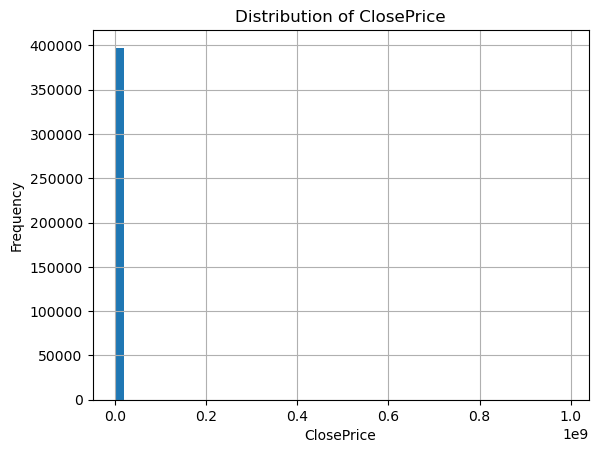

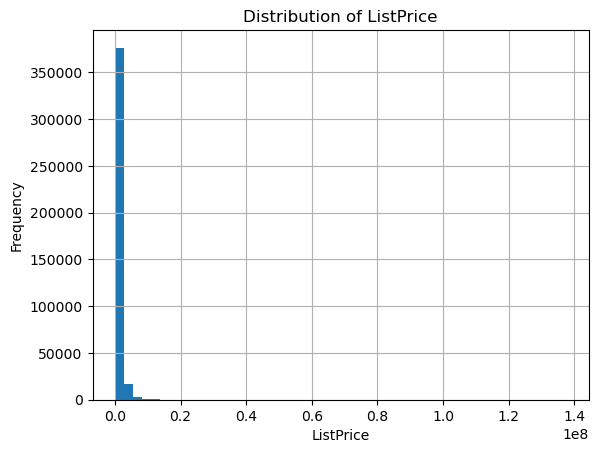

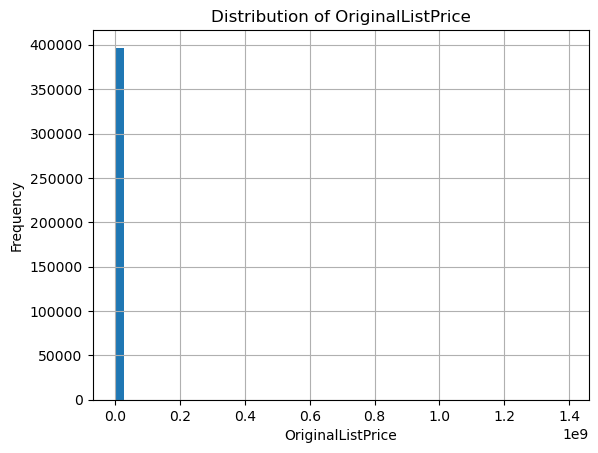

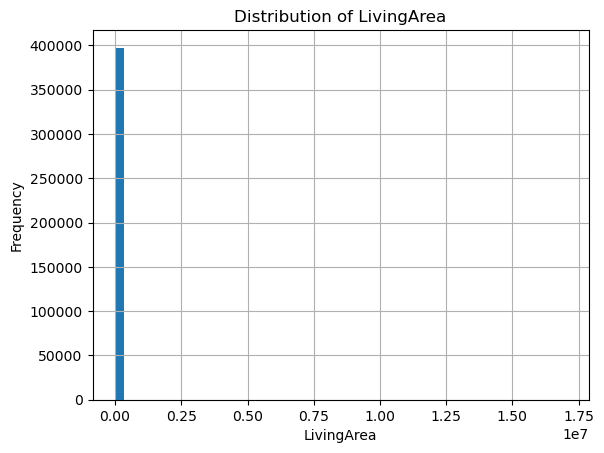

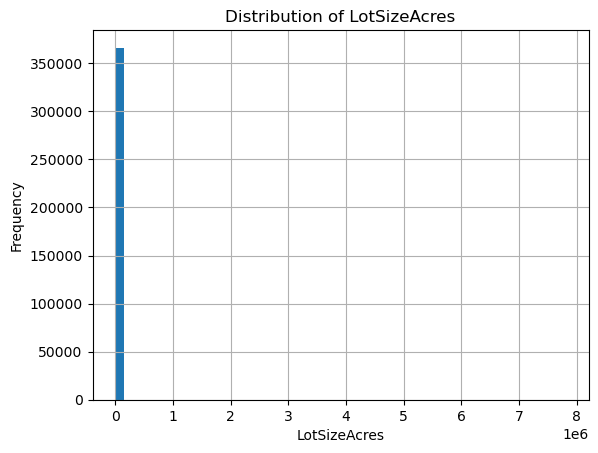

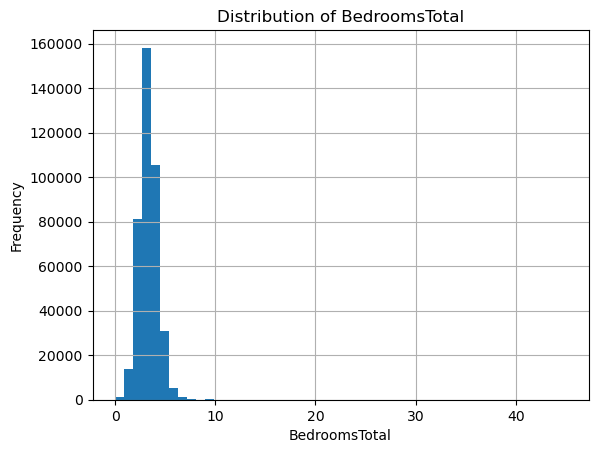

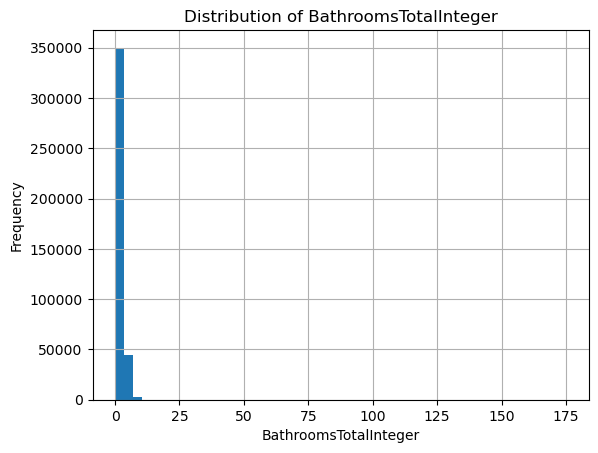

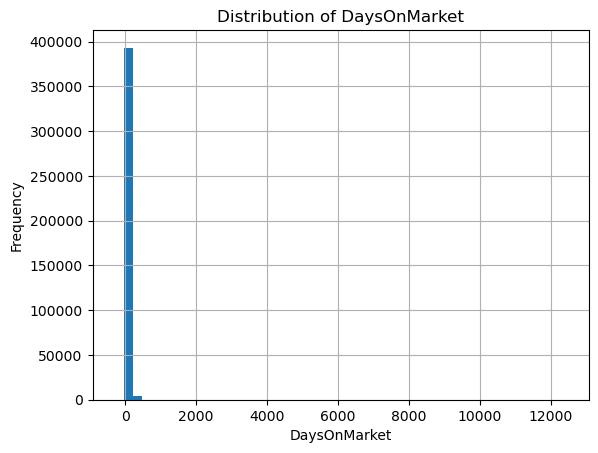

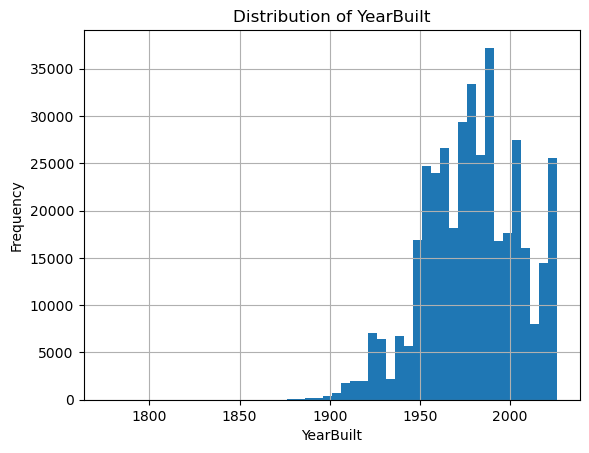

In [31]:
import matplotlib.pyplot as plt

# Loop through each column and plot histogram
for col in numeric_cols:
    plt.figure()
    sold[col].hist(bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

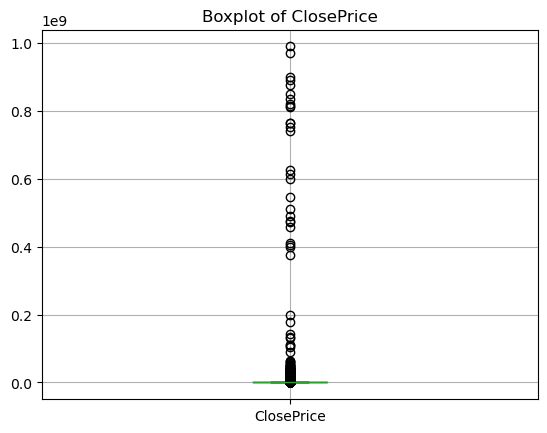

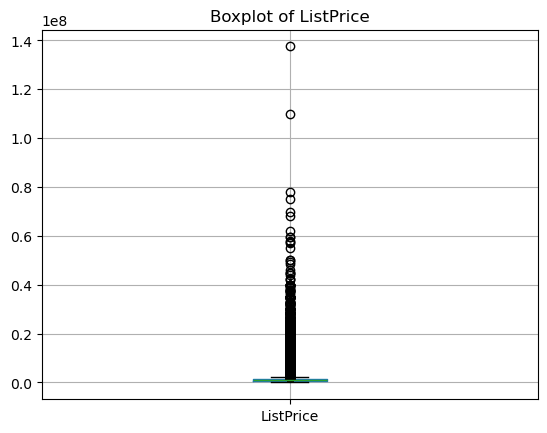

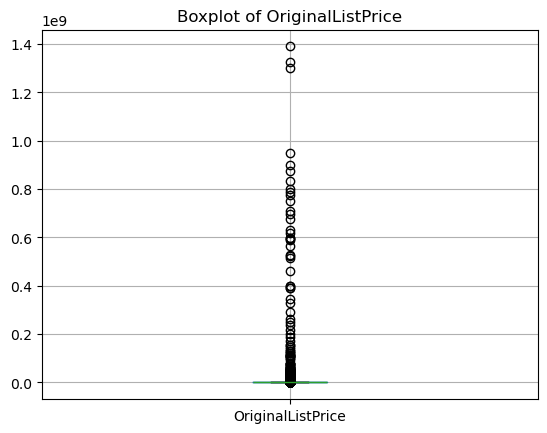

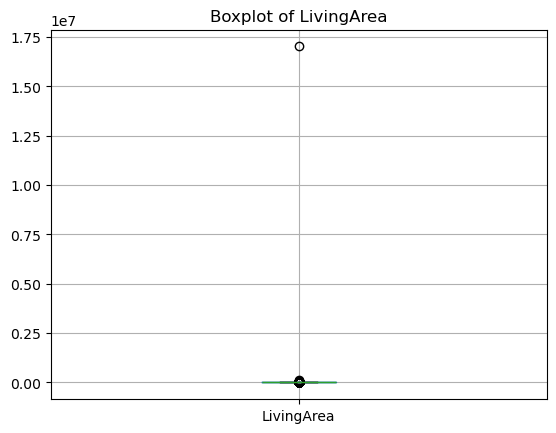

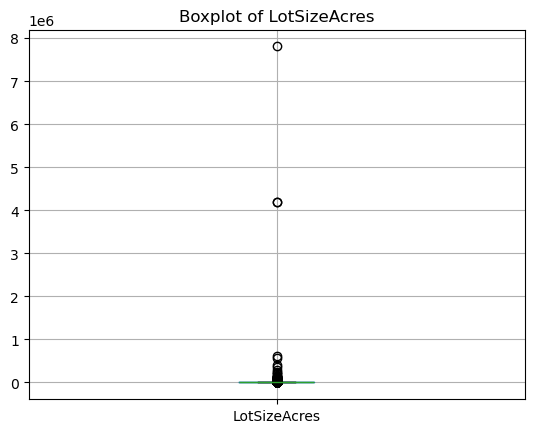

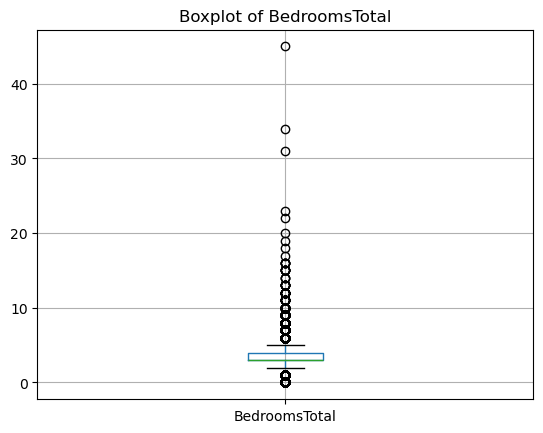

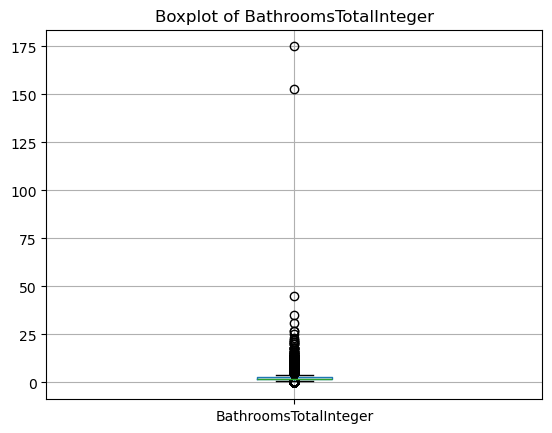

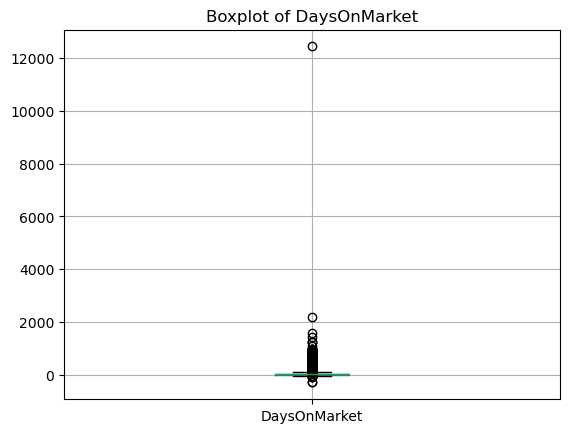

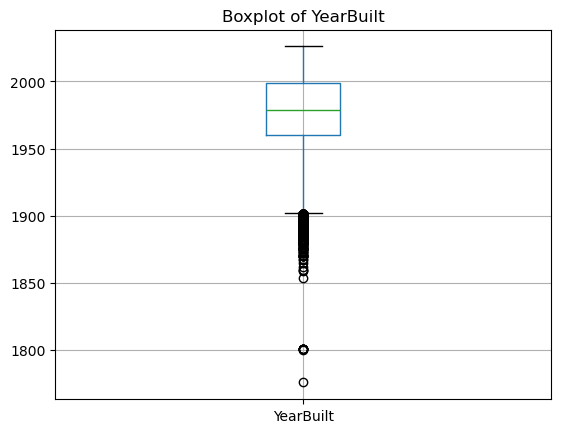

In [32]:
# Boxplots help identify extreme values
for col in numeric_cols:
    plt.figure()
    sold.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [33]:
# Example: find suspicious values
for col in numeric_cols:
    print(f"\nColumn: {col}")
    print("Min:", sold[col].min())
    print("Max:", sold[col].max())


Column: ClosePrice
Min: 0.0
Max: 989500000.0

Column: ListPrice
Min: 525.0
Max: 137500000.0

Column: OriginalListPrice
Min: 0.0
Max: 1390000000.0

Column: LivingArea
Min: 0.0
Max: 17021321.0

Column: LotSizeAcres
Min: 0.0
Max: 7810698.3564

Column: BedroomsTotal
Min: 0.0
Max: 45.0

Column: BathroomsTotalInteger
Min: 0.0
Max: 175.0

Column: DaysOnMarket
Min: -288
Max: 12430

Column: YearBuilt
Min: 1776.0
Max: 2026.0


The numeric distribution analysis revealed several data quality issues. Key variables such as ClosePrice, LivingArea, and LotSizeAcres contain invalid values (e.g., zeros) and extreme outliers (e.g., unusually high maximum values). Additionally, fields like YearBuilt include implausible values such as future dates. These observations indicate the need for data cleaning and outlier handling in subsequent steps.

In [34]:
# Count invalid values
print("ClosePrice = 0:", (sold['ClosePrice'] == 0).sum())
print("LivingArea = 0:", (sold['LivingArea'] == 0).sum())
print("DaysOnMarket < 0:", (sold['DaysOnMarket'] < 0).sum())

ClosePrice = 0: 1
LivingArea = 0: 144
DaysOnMarket < 0: 46


In [35]:
sold['ClosePrice'].median()

820000.0

In [36]:
sold['ClosePrice'].mean()

1185616.3601253766

### Suggested Intern Questions

What is the Residential vs. other property type share?

In [37]:
# Check distribution of property types
sold['PropertyType'].value_counts(normalize=True) * 100

PropertyType
Residential    100.0
Name: proportion, dtype: float64

What are the median and average close prices?

In [38]:
# Median price
median_price = sold['ClosePrice'].median()

# Mean price
mean_price = sold['ClosePrice'].mean()

print("Median Close Price:", median_price)
print("Average Close Price:", mean_price)

Median Close Price: 820000.0
Average Close Price: 1185616.3601253766


What does the Days on Market distribution look like?

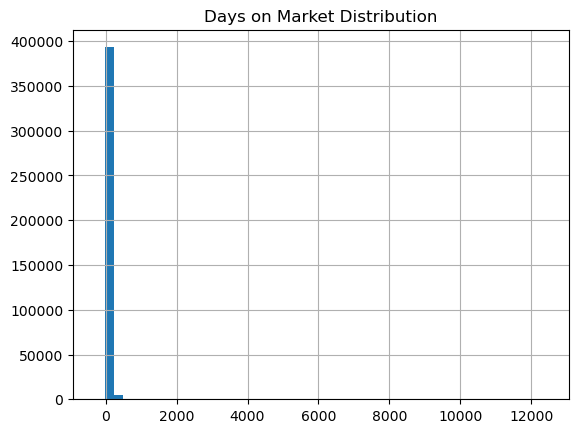

In [39]:
# Summary
sold['DaysOnMarket'].describe()

# Histogram
sold['DaysOnMarket'].hist(bins=50)
plt.title("Days on Market Distribution")
plt.show()

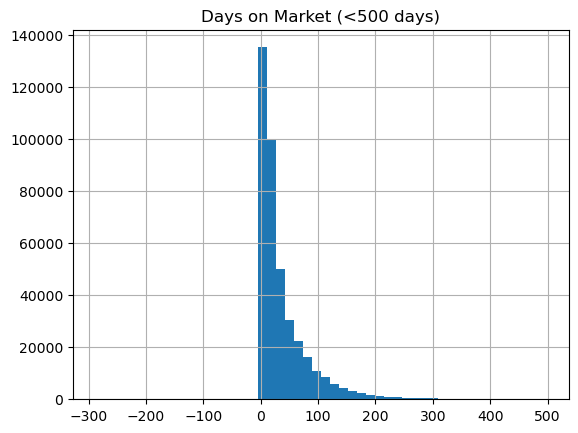

In [40]:
sold[sold['DaysOnMarket'] < 500]['DaysOnMarket'].hist(bins=50)
plt.title("Days on Market (<500 days)")
plt.show()

The Days on Market distribution is right-skewed, with most properties selling within 0–100 days. The histogram shows a strong concentration of values at the lower range, indicating that the majority of homes sell relatively quickly. A gradual decline toward higher values suggests that some properties take longer to sell.

What percentage of homes sold above vs. below list price?

In [41]:
# Above list
above = (sold['ClosePrice'] > sold['ListPrice']).mean() * 100

# Below list
below = (sold['ClosePrice'] < sold['ListPrice']).mean() * 100

print("Above List %:", above)
print("Below List %:", below)

Above List %: 40.11111586180185
Below List %: 42.544447602256525


Note to myself:

Close > List → buyer paid MORE (competitive market)

Close < List → buyer paid LESS (negotiation)

Close = List → exact match

From the above analysis:

40% above list → buyers are competing with each other

42% below list → slightly strong negotiation happening

About 40% of homes sold above the list price, and about 42% sold below it. This means the market is fairly balanced. Slightly more homes are selling below the asking price, which could mean buyers have a bit more negotiating power.

Are there any apparent date consistency issues (e.g., close date before listing date)?

In [42]:
# Convert to datetime
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'])

# Check invalid cases
invalid_dates = (sold['CloseDate'] < sold['ListingContractDate']).sum()

print("Invalid date records:", invalid_dates)

Invalid date records: 58


There are 58 records where the CloseDate occurs before the ListingContractDate, which indicates data inconsistencies. These cases are logically invalid since a property cannot be sold before it is listed. These records will need to be addressed during the data cleaning phase.

Which counties have the highest median prices?

In [43]:
# Group by county and compute median price
county_prices = sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False)

county_prices.head(10)

CountyOrParish
Del Norte        2485000.0
Other County     2462500.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Name: ClosePrice, dtype: float64

Counties like San Mateo, Santa Clara, and San Francisco have the highest home prices, which shows that these areas are in high demand. This means sellers can set higher prices, while buyers may find it harder to afford homes. These areas are also good opportunities for investors because property values are high. Overall, this shows that housing markets can vary a lot by location, so strategies should depend on the area.

### Mortgage Rate Enrichment
Enrich both the combined sold and listings datasets by merging in the national 30-year fixed mortgage
rate from the St. Louis Federal Reserve (FRED). This introduces interns to fetching live economic data
from a public API and performing a time-series join on a monthly key.

### Objective
Fetch the FRED MORTGAGE30US series, resample it from weekly to monthly frequency, and merge it
onto both combined datasets using a year-month key derived from transaction dates.

### Background
The FRED MORTGAGE30US series is published weekly (every Thursday) by Freddie Mac via the St.
Louis Federal Reserve. Because MLS transactions are analyzed by calendar month, interns must
resample the weekly data to a monthly average before joining. The data can be fetched directly from
FRED as a CSV—no API key required.

In [ ]:
# Fetch mortgage rate data from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

mortgage = pd.read_csv(url, parse_dates=['observation_date'])


In [88]:
mortgage.columns

Index(['observation_date', 'MORTGAGE30US'], dtype='object')

In [89]:
# Rename columns for clarity
mortgage.columns = ['date', 'rate_30yr_fixed']

In [90]:
# Convert weekly to monthly average
# Create year-month column
mortgage['year_month'] = mortgage['date'].dt.to_period('M')

# Take average rate per month
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

In [91]:
mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [92]:
# Create year_month in your datasets
# For SOLD -> use CloseDate
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'], errors='coerce')
sold['year_month'] = sold['CloseDate'].dt.to_period('M')

# For LISTINGS -> use ListingContractDate
listings['ListingContractDate'] = pd.to_datetime(listings['ListingContractDate'], errors='coerce')
listings['year_month'] = listings['ListingContractDate'].dt.to_period('M')

In [93]:
# Merge mortgage rates
# Left join so we keep all rows
sold_with_rates = sold.merge(mortgage_monthly, on='year_month', how='left')
listings_with_rates = listings.merge(mortgage_monthly, on='year_month', how='left')

In [94]:
sold_with_rates.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,year_month,rate_30yr_fixed
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN,2024-01,6.6425
1,SanDiego,SanDiego,NaN,False,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,2024-01,6.6425
2,SanDiego,SanDiego,NaN,False,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,2024-01,6.6425
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,1079166779,davidmartz@compass.com,2024-01-30,858000.0,...,Palm Springs Unified,92262,NaN,13504.0,NaN,NaN,NaN,NaN,2024-01,6.6425
4,Southland,Southland,NaN,False,False,1890500.0,1075037759,karen.klein@theagencyre.com,2024-01-29,1890500.0,...,Los Angeles Unified,91356,0.0,17873.0,NaN,NaN,NaN,NaN,2024-01,6.6425


In [95]:
listings_with_rates.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,year_month,rate_30yr_fixed
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,NaN,NaN,90067,NaN,2105.00,177861.0,2220 Avenue Of The Stars 2704,2024-01,6.6425
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,16 Palisades,2024-01,6.6425
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,2.0,NaN,91108,NaN,NaN,9404.0,1615 Waverly Road,2024-01,6.6425
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,2250 Indian Creek Road,2024-01,6.6425
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,317 E. Bayfront,2024-01,6.6425


In [96]:
# Validate merge (VERY IMPORTANT)
print("Missing rates in SOLD:", sold_with_rates['rate_30yr_fixed'].isnull().sum())
print("Missing rates in LISTINGS:", listings_with_rates['rate_30yr_fixed'].isnull().sum())

Missing rates in SOLD: 0
Missing rates in LISTINGS: 0


In [97]:
print(sold_with_rates[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01    240000.0           6.6425
1 2024-01-05    2024-01    815000.0           6.6425
2 2024-01-05    2024-01    810000.0           6.6425
3 2024-01-30    2024-01    858000.0           6.6425
4 2024-01-29    2024-01   1890500.0           6.6425


In [98]:
# Save final enriched datasets
# sold_with_rates.to_csv("RAW/sold_enriched.csv.gz", index=False, compression='gzip')
# listings_with_rates.to_csv("RAW/listings_enriched.csv.gz", index=False, compression='gzip')

# Need to discuss. -> [Errno 28] No space left on device


## Weeks 4–5 – Data Cleaning and Preparation

### Tasks

• Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate,
ContractStatusChangeDate)


• Remove unnecessary or redundant columns

• Handle missing values appropriately

• Ensure numeric fields are properly typed

• Remove or flag invalid numeric values: ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0,
negative Bedrooms or Bathrooms

### Convert date fields to datetime format

In [99]:
sold_with_rates[['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']]

,CloseDate,PurchaseContractDate,ListingContractDate,ContractStatusChangeDate
0,2024-01-26,2023-11-22,2021-10-06,2024-01-26
1,2024-01-05,2021-06-30,2021-03-08,2024-01-05
2,2024-01-05,2021-11-18,2021-03-08,2024-01-05
3,2024-01-30,2024-08-05,2024-01-30,2024-01-30
4,2024-01-29,2024-01-29,2024-01-29,2024-01-29
...,...,...,...,...
397598,2026-03-10,2026-01-30,2023-11-16,2026-03-10
397599,2026-03-20,2026-01-12,2023-09-21,2026-03-20
397600,2026-03-30,2026-01-31,2023-05-21,2026-03-30
397601,2026-03-13,2026-02-13,2023-05-19,2026-03-13


In [100]:
listings_with_rates[['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']]

,CloseDate,PurchaseContractDate,ListingContractDate,ContractStatusChangeDate
0,NaN,2024-05-07,2024-01-01,2024-05-07
1,NaN,NaN,2024-01-24,2024-01-24
2,NaN,NaN,2024-01-12,2024-01-12
3,NaN,NaN,2024-01-20,2024-01-20
4,NaN,NaN,2024-01-12,2024-01-12
...,...,...,...,...
540178,NaN,NaN,2026-03-07,2026-03-07
540179,NaN,NaN,2026-03-24,2026-03-24
540180,NaN,2026-03-20,2026-03-12,2026-03-20
540181,NaN,NaN,2026-03-18,2026-03-18


In [101]:
# SOLD
sold_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]
sold_with_rates[sold_date_cols].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate                object
ListingContractDate         datetime64[ns]
ContractStatusChangeDate            object
dtype: object

In [102]:
# SOLD
sold_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]

for col in sold_date_cols:
    if col in sold_with_rates.columns:
        sold_with_rates[col] = pd.to_datetime(sold_with_rates[col], errors='coerce')

In [103]:
sold_with_rates[sold_date_cols].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate        datetime64[ns]
ListingContractDate         datetime64[ns]
ContractStatusChangeDate    datetime64[ns]
dtype: object

In [104]:
# LISTNGS 
listings_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]
listings_with_rates[listings_date_cols].dtypes

CloseDate                           object
PurchaseContractDate                object
ListingContractDate         datetime64[ns]
ContractStatusChangeDate            object
dtype: object

In [105]:
# LISTINGS
listings_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]

for col in listings_date_cols:
    if col in listings_with_rates.columns:
        listings_with_rates[col] = pd.to_datetime(listings_with_rates[col], errors='coerce')

In [106]:
listings_with_rates[listings_date_cols].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate        datetime64[ns]
ListingContractDate         datetime64[ns]
ContractStatusChangeDate    datetime64[ns]
dtype: object

### Remove unnecessary or redundant columns


In [107]:
print(sold_with_rates.columns)

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince',

In ML: You remove highly correlated features to avoid redundancy

But here in this project: We are doing analysis + insights, not prediction

Therefore Correlation is useful, not something to eliminate

In [109]:
sold_with_rates[['BuyerAgentAOR', 'ListAgentAOR']]

,BuyerAgentAOR,ListAgentAOR
0,Mlslistings,Mlslistings
1,SanDiego,SanDiego
2,SanDiego,SanDiego
3,Mlslistings,Mlslistings
4,Southland,Southland
...,...,...
397598,InlandValleys,InlandValleys
397599,HighDesert,HighDesert
397600,Mrmls,TheInlandGateway
397601,CaliforniaDesert,CaliforniaDesert


In [110]:
(sold_with_rates['BuyerAgentAOR'] == sold_with_rates['ListAgentAOR']).sum()

336248

In [111]:
match_percent = (
    (sold_with_rates['BuyerAgentAOR'] == sold_with_rates['ListAgentAOR'])
    .mean() * 100
)

print(f"Match %: {match_percent:.2f}%")

Match %: 84.57%


In [112]:
sold_with_rates[['LotSizeAcres', 'LotSizeSquareFeet']].head()

# they represent the same information, just in different units.
# LotSizeAcres = acres
# LotSizeSquareFeet = square feet

# 0.3100 acres → 0.3100 × 43560 ≈ 13504 square feet

,LotSizeAcres,LotSizeSquareFeet
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,0.3100,13504.0
4,0.4103,17873.0


In [ ]:
# Columns to remove from the dataset
cols_to_drop = [

    # -------- Agent name redundancy --------
    # These columns split agent names into first/last,
    # but we already have full name columns, therefore this is redundant
    'ListAgentFirstName',
    'ListAgentLastName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',

    # BuyerAgentAOR is highly similar to ListAgentAOR,
    # so it is removed to avoid redundancy
    'BuyerAgentAOR',
    'BuyerAgentMlsId',

    # -------- Address-level details --------
    # Too detailed for this project (we analyze by county/city, not exact address)
    'StreetNumberNumeric',
    'UnparsedAddress',

    # PostalCode is optional; dropped here since analysis is at county level,
    # but can be retained if zip-level analysis is required later
    'PostalCode',   

    
    # -------- Duplicate size information --------
    # Lot size is already available in acres, this one is square feet which is redundant
    'LotSizeSquareFeet',

    # -------- Redundant bedroom information --------
    # MainLevelBedrooms was removed because it provides partial information about bedroom distribution, while BedroomsTotal already captures the total number of bedrooms.
    'MainLevelBedrooms',

    

]

# Drop the selected columns
# errors='ignore' ensures code does not break if any column is missing
sold_with_rates = sold_with_rates.drop(columns=cols_to_drop, errors='ignore')

Column removal was guided by business relevance and analytical usefulness rather than statistical correlation. Since this project focuses on market analysis rather than predictive modeling, variables that are correlated with price (e.g., LivingArea, ListPrice) were retained as they provide meaningful insights into housing trends. Redundant columns were identified based on overlapping information (e.g., lot size in different units), and columns with high missing values or low analytical value were removed.

MainLevelBedrooms was removed because it provides partial information about bedroom distribution, while BedroomsTotal already captures the total number of bedrooms. Since the analysis focuses on overall property characteristics rather than layout-specific details, this column was considered redundant.

In [115]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'AssociationFeeFrequency',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR',
       'YearBuilt', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'MiddleOrJuniorSchool',
       'FireplaceYN', 'Stories', 'HighSchool', 'Levels', 'LotSizeArea',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'AssociationFee', 'BuyerAgencyCompensationType',
       'BuyerAg

In [116]:
missing_percent_sold_rates = sold_with_rates.isnull().mean() * 100

# show columns with high missing values
print(missing_percent_sold_rates.sort_values(ascending=False).head(25))

BuyerAgencyCompensation        88.399232
BuyerAgencyCompensationType    88.396466
ElementarySchool               86.676157
MiddleOrJuniorSchool           86.587123
lonfilled                      83.932717
latfilled                      83.932717
HighSchool                     82.583129
CoListOfficeName               76.337704
SubdivisionName                62.845351
AssociationFeeFrequency        58.361984
Flooring                       35.862405
HighSchoolDistrict             27.378315
AssociationFee                 22.886648
Stories                        15.468445
AttachedGarageYN               15.261203
MLSAreaMajor                   13.360563
ListAgentAOR                   11.616110
Levels                          9.700380
PoolPrivateYN                   8.660649
ViewYN                          8.518296
LotSizeAcres                    7.888270
LotSizeArea                     7.762265
NewConstructionYN               7.407640
ListAgentEmail                  7.296726
BuyerOfficeAOR  

In [125]:
sold_with_rates[['SubdivisionName']]

,SubdivisionName
0,NaN
1,National City
2,National City
3,NaN
4,NaN
...,...
397598,NaN
397599,NaN
397600,NaN
397601,Not Applicable-1


In [126]:
corr_with_price = sold_with_rates.corr(numeric_only=True)['ClosePrice'] \
    .sort_values(ascending=False)

print(corr_with_price)

ClosePrice                 1.000000
ListPrice                  0.213070
BathroomsTotalInteger      0.110617
BedroomsTotal              0.075051
OriginalListPrice          0.043467
Stories                    0.034359
BuyerAgencyCompensation    0.031699
GarageSpaces               0.011454
AssociationFee             0.006449
DaysOnMarket               0.005631
ListingKey                 0.005078
ListingKeyNumeric          0.005078
LivingArea                 0.004715
LotSizeArea                0.003971
LotSizeAcres               0.000284
YearBuilt                 -0.000211
ParkingTotal              -0.000245
rate_30yr_fixed           -0.000863
Latitude                  -0.002906
Longitude                 -0.011931
Name: ClosePrice, dtype: float64


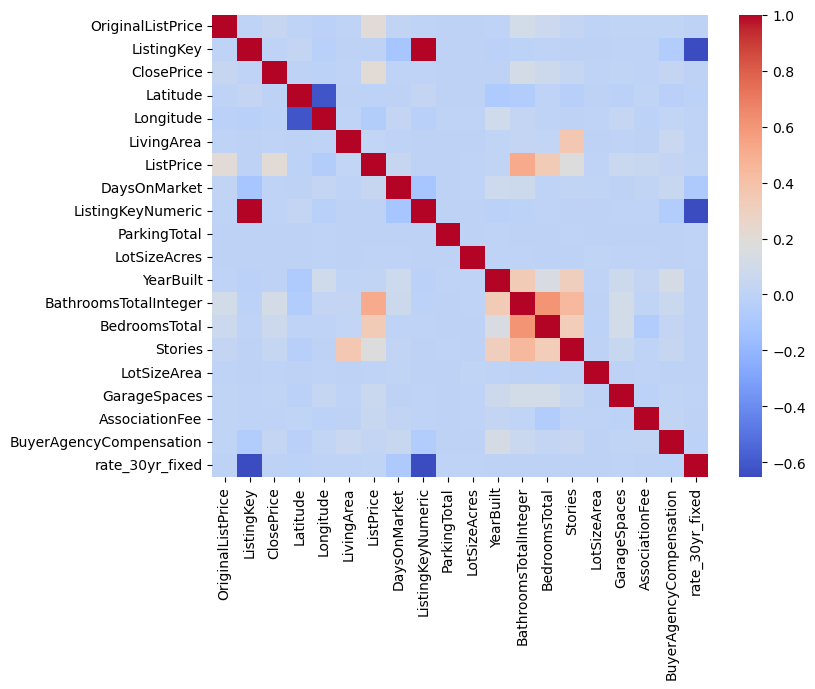

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(sold_with_rates.corr(numeric_only=True), cmap='coolwarm')
plt.show()

In [129]:
additional_drop = [

    # high missing + low value
    'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType',
    'AssociationFeeFrequency',

    # school columns
    'ElementarySchool',
    'MiddleOrJuniorSchool',
    'HighSchool',

    # likely flags 
    'latfilled',
    'lonfilled',

    # too granular
    'SubdivisionName',
 
]

sold_with_rates = sold_with_rates.drop(columns=additional_drop, errors='ignore')

In [131]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'AttachedGarageYN',
       'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'BuyerOfficeAOR',
       'YearBuilt', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'AssociationFee', 'year_month',
       'rate_30yr_fixed'],
      dtype='object')

In [133]:
missing_percent_sold_rates = sold_with_rates.isnull().mean() * 100

# show columns with high missing values
print(missing_percent_sold_rates.sort_values(ascending=False).head(25))

CoListOfficeName            76.337704
Flooring                    35.862405
HighSchoolDistrict          27.378315
AssociationFee              22.886648
Stories                     15.468445
AttachedGarageYN            15.261203
MLSAreaMajor                13.360563
ListAgentAOR                11.616110
Levels                       9.700380
PoolPrivateYN                8.660649
ViewYN                       8.518296
LotSizeAcres                 7.888270
LotSizeArea                  7.762265
NewConstructionYN            7.407640
ListAgentEmail               7.296726
BuyerOfficeAOR               5.393822
GarageSpaces                 4.288952
Longitude                    3.979346
Latitude                     3.979346
BuyerOfficeName              1.644354
PropertySubType              0.195170
OriginalListPrice            0.181337
ContractStatusChangeDate     0.148138
ParkingTotal                 0.107142
YearBuilt                    0.089537
dtype: float64


In [134]:
# Additional columns to drop (refined)
additional_drop = [

    # -------- IDs / identifiers (not useful for analysis) --------
    'ListingKey',
    'ListingKeyNumeric',

    # -------- Contact / sensitive info --------
    'ListAgentEmail',
        'ListAgentFirstName',
        'ListAgentLastName',
        'BuyerAgentFirstName',
        'BuyerAgentLastName'

]

# Drop columns safely
sold_with_rates = sold_with_rates.drop(columns=additional_drop, errors='ignore')

In [135]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'BuyerOfficeAOR', 'YearBuilt', 'ListingId', 'BathroomsTotalInteger',
       'City', 'BedroomsTotal', 'ContractStatusChangeDate',
       'PurchaseContractDate', 'ListingContractDate', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'AssociationFee', 'year_month',
       'rate_30yr_fixed'],
      dtype='object')

In [136]:
sold_with_rates.shape

(397603, 44)

In [137]:
final_drop = [

    # IDs
    'ListingId',

    # redundant size column, we have LotSizeAcres
    'LotSizeArea',

]

sold_with_rates = sold_with_rates.drop(columns=final_drop, errors='ignore')

In [139]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'BuyerOfficeAOR', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'AssociationFee', 'year_month', 'rate_30yr_fixed'],
      dtype='object')

### Remove unnecessary or redundant columns from listings_with_rates

In [140]:
listings_with_rates.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName',
       'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation',
       'BedroomsTotal', 'ContractStatusChangeDate', 'Lo

In [143]:
missing_percent_listings_rates = listings_with_rates.isnull().mean() * 100

print(missing_percent_listings_rates.sort_values(ascending=False).head(25))

ElementarySchool               88.089592
MiddleOrJuniorSchool           88.062934
BuyerAgencyCompensation        85.376622
BuyerAgencyCompensationType    85.372920
HighSchool                     84.363447
CoListAgentFirstName           77.685340
CoListAgentLastName            77.611106
CoListOfficeName               77.595370
ClosePrice                     73.049874
BuyerOfficeAOR                 72.839760
BuyerOfficeName                70.945032
BuyerOfficeName.1              70.945032
BuyerAgentFirstName            70.661979
BuyerAgentMlsId                70.547574
BuyerAgentLastName             70.527210
CloseDate.1                    69.302625
CloseDate                      69.302625
SubdivisionName                63.172851
AssociationFeeFrequency        57.263187
PurchaseContractDate           50.555275
MainLevelBedrooms              45.554007
HighSchoolDistrict             30.065367
AssociationFee                 24.003347
AttachedGarageYN               17.477966
Stories         

In [146]:
pairs = [
    ('LivingArea', 'LivingArea.1'),
    ('CloseDate', 'CloseDate.1'),
    ('Longitude', 'Longitude.1'),
    ('ListPrice', 'ListPrice.1')
]

for col1, col2 in pairs:
    match = (listings_with_rates[col1].fillna(-1) == listings_with_rates[col2].fillna(-1)).mean()
    print(f"{col1} vs {col2}: {match*100:.2f}% match")

LivingArea vs LivingArea.1: 100.00% match
CloseDate vs CloseDate.1: 69.30% match
Longitude vs Longitude.1: 100.00% match
ListPrice vs ListPrice.1: 100.00% match


In [147]:
# Columns to remove from listings dataset
listings_drop = [

    # -------- IDs (not useful for analysis) --------
    # Just identifiers, not used in analysis
    'ListingKey',
    'ListingKeyNumeric',

    # -------- Contact / name splits --------
    # Email is sensitive and not useful
    # First/Last names are redundant (full name already exists)
    'ListAgentEmail',
    'ListAgentFirstName',
    'ListAgentLastName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',

    # -------- Buyer-related columns --------
    # Not needed since we are not doing buyer-side analysis
    'BuyerAgentMlsId',
    'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType',
    'BuyerOfficeAOR',
    'BuyerOfficeName',
    'BuyerOfficeName.1',

    # -------- School columns --------
    # Very high missing values and not relevant for this analysis
    'ElementarySchool',
    'MiddleOrJuniorSchool',
    'HighSchool',

    # -------- Duplicate size info --------
    # Same info as LotSizeAcres (just different unit)
    'LotSizeSquareFeet',

    # -------- Redundant bedroom info --------
    # BedroomsTotal already gives total bedrooms
    'MainLevelBedrooms',

    # -------- Address-level details --------
    # Too detailed, not needed for county-level analysis
    'UnparsedAddress',
    'UnparsedAddress.1',
    'StreetNumberNumeric',
    'SubdivisionName',

    # -------- Duplicate columns (.1 versions) --------
    # These are repeated versions of existing columns
    'LivingArea.1',
    'Longitude.1',
    'ListPrice.1',

    # -------- Low-value column --------
    # High missing and not important for analysis
    'AssociationFeeFrequency'
]

# Drop columns safely
# errors='ignore' prevents errors if a column is not present
listings_with_rates = listings_with_rates.drop(columns=listings_drop, errors='ignore')

In [148]:
listings_with_rates.shape

(540183, 45)

### Remove or flag invalid numeric values: ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0, negative Bedrooms or Bathrooms

#### Remove or flag invalid numeric values from sold_with_rates

In [149]:
# Remove invalid records where ClosePrice is 0 or negative, as these are likely data errors
sold_with_rates = sold_with_rates[
    (sold_with_rates['ClosePrice'] > 0) &
    (sold_with_rates['LivingArea'] > 0) &
    (sold_with_rates['DaysOnMarket'] >= 0) &
    (sold_with_rates['BedroomsTotal'] >= 0) &
    (sold_with_rates['BathroomsTotalInteger'] >= 0)
]

In [150]:
# Flag invalid numeric values in sold_with_rates
sold_with_rates['invalid_flag'] = (
    (sold_with_rates['ClosePrice'] <= 0) |
    (sold_with_rates['LivingArea'] <= 0) |
    (sold_with_rates['DaysOnMarket'] < 0) |
    (sold_with_rates['BedroomsTotal'] < 0) |
    (sold_with_rates['BathroomsTotalInteger'] < 0)
)

sold_with_rates['invalid_flag'].sum()

0

#### Remove or flag invalid numeric values from listings_with_rates

In [151]:
# Remove invalid values from listings_with_rates
listings_with_rates = listings_with_rates[
    (listings_with_rates['ListPrice'] > 0) &
    (listings_with_rates['LivingArea'] > 0) &
    (listings_with_rates['DaysOnMarket'] >= 0) &
    (listings_with_rates['BedroomsTotal'] >= 0) &
    (listings_with_rates['BathroomsTotalInteger'] >= 0)
]

In [152]:
# Flag invalid values
listings_with_rates['invalid_flag'] = (
    (listings_with_rates['ListPrice'] <= 0) |
    (listings_with_rates['LivingArea'] <= 0) |
    (listings_with_rates['DaysOnMarket'] < 0) |
    (listings_with_rates['BedroomsTotal'] < 0) |
    (listings_with_rates['BathroomsTotalInteger'] < 0)
)

In [153]:
listings_with_rates['invalid_flag'].sum()

0

Invalid numeric values were identified and handled by filtering out records with non-positive prices, non-positive living area, negative days on market, and negative bedroom or bathroom counts. Additionally, flag variables were created to track such invalid entries for transparency and validation purposes.

### Handle missing values appropriately

In [158]:
sold_with_rates.head()

,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,...,FireplaceYN,Stories,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,AssociationFee,year_month,rate_30yr_fixed,invalid_flag
0,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,2024-01-26,240000.0,NaN,NaN,Residential,...,True,NaN,NaN,False,1.0,Other,6472.0,2024-01,6.6425,False
1,SanDiego,NaN,False,False,759900.0,2024-01-05,815000.0,NaN,NaN,Residential,...,False,2.0,Two,False,2.0,NaN,NaN,2024-01,6.6425,False
2,SanDiego,NaN,False,False,739900.0,2024-01-05,810000.0,NaN,NaN,Residential,...,False,2.0,Two,False,2.0,NaN,NaN,2024-01,6.6425,False
3,Mlslistings,NaN,False,NaN,NaN,2024-01-30,858000.0,NaN,NaN,Residential,...,False,NaN,NaN,False,2.0,Palm Springs Unified,NaN,2024-01,6.6425,False
4,Southland,NaN,False,False,1890500.0,2024-01-29,1890500.0,34.164376,-118.558749,Residential,...,True,1.0,One,False,2.0,Los Angeles Unified,0.0,2024-01,6.6425,False


In [163]:
# Combine missing values and data types
missing_info = pd.DataFrame({
    'Missing_Count': sold_with_rates.isnull().sum(),
    'Missing_%': sold_with_rates.isnull().mean() * 100,
    'Data_Type': sold_with_rates.dtypes
})

# Sort by missing count
missing_info = missing_info.sort_values(by='Missing_Count', ascending=False)

print(missing_info.head(25))

                          Missing_Count  Missing_%       Data_Type
CoListOfficeName                 303196  76.348134          object
Flooring                         142387  35.854634          object
HighSchoolDistrict               108511  27.324280          object
AssociationFee                    90742  22.849848         float64
Stories                           61404  15.462212         float64
AttachedGarageYN                  60412  15.212415          object
MLSAreaMajor                      53098  13.370669          object
ListAgentAOR                      46117  11.612775          object
Levels                            38530   9.702284          object
PoolPrivateYN                     34323   8.642914          object
ViewYN                            33855   8.525067          object
LotSizeAcres                      31316   7.885718         float64
NewConstructionYN                 29424   7.409291          object
BuyerOfficeAOR                    21420   5.393795          ob

In [164]:
print(missing_info.tail(20))

                       Missing_Count  Missing_%       Data_Type
YearBuilt                        296   0.074536         float64
FireplaceYN                      273   0.068744          object
PurchaseContractDate             194   0.048851  datetime64[ns]
ListAgentFullName                 85   0.021404          object
ListingContractDate                1   0.000252  datetime64[ns]
MlsStatus                          0   0.000000          object
LivingArea                         0   0.000000         float64
rate_30yr_fixed                    0   0.000000         float64
year_month                         0   0.000000       period[M]
CloseDate                          0   0.000000  datetime64[ns]
ClosePrice                         0   0.000000         float64
PropertyType                       0   0.000000          object
StateOrProvince                    0   0.000000          object
ListPrice                          0   0.000000         float64
DaysOnMarket                       0   0